# Triângulos Quaisquer

**Módulo:** 05 – Trigonometria (10º e último notebook do módulo)

**Pré-requisitos:** [`0509a_triangulos_retangulos.ipynb`](0509a_triangulos_retangulos.ipynb) (o triângulo retângulo é o caso particular usado nas deduções deste notebook) e [`0505a_arcos_notaveis.ipynb`](0505a_arcos_notaveis.ipynb) (valores exatos usados nos exemplos)

**Objetivos de aprendizagem:**
- Revisar as propriedades geométricas gerais de qualquer triângulo (soma dos ângulos, desigualdade triangular, classificação).
- Deduzir e aplicar a Lei dos Senos para resolver triângulos a partir de ângulos e lados conhecidos.
- Deduzir e aplicar a Lei dos Cossenos, generalizando o Teorema de Pitágoras para triângulos quaisquer.
- Calcular a área de um triângulo usando trigonometria e resolver problemas completos de triangulação e navegação.

**Tempo estimado:** 90 a 115 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/05_trigonometria/0510a_triangulos_quaisquer.ipynb)

Como você mediria a distância até uma ilha no meio de um lago, sem poder chegar até ela? Ou como um navio, antes do GPS, conseguia calcular sua posição exata no meio do oceano apenas observando ângulos e distâncias percorridas?

A resposta para os dois problemas está em uma ferramenta que ainda falta no nosso kit: até agora, só sabemos resolver triângulos que têm um ângulo reto. Mas a maioria dos triângulos do mundo real não tem.

Os dois problemas são resolvidos por completo nos Blocos 2 e 3 — e retomados juntos, num desafio final, no Bloco 6.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)

## 1. Propriedades Geométricas de um Triângulo Qualquer

Em qualquer triângulo — não só nos retângulos — valem duas propriedades fundamentais:

- **Soma dos ângulos internos:** A + B + C = 180°, sempre.
- **Desigualdade triangular:** a soma de dois lados quaisquer é sempre maior que o terceiro lado (a + b > c, a + c > b, b + c > a). Se essa condição falhar, os três segmentos nem chegam a fechar um triângulo.

Também é possível classificar um triângulo de duas formas independentes:

- **Pelos lados:** equilátero (três lados iguais), isósceles (dois lados iguais) ou escaleno (três lados diferentes).
- **Pelos ângulos:** acutângulo (três ângulos agudos), retângulo (um ângulo de 90°) ou obtusângulo (um ângulo maior que 90°).

A partir de agora, nenhum ângulo é necessariamente reto — os "atalhos" de cateto e hipotenusa vistos em [`0509a_triangulos_retangulos.ipynb`](0509a_triangulos_retangulos.ipynb) não se aplicam mais. Precisamos de ferramentas novas.

,"lados (a, b, c)",válido?,classificação
0,"(5, 5, 5)",True,equilátero
1,"(5, 5, 8)",True,isósceles
2,"(4, 5, 6)",True,escaleno


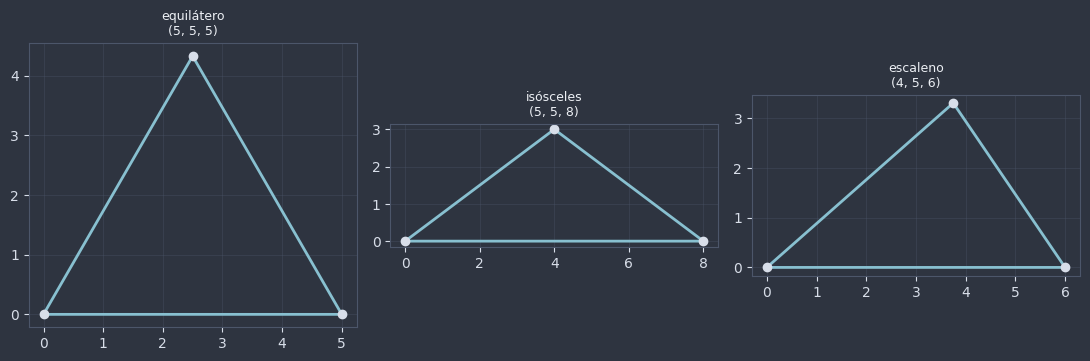

60-60-60°: acutângulo
90-45-45°: retângulo
100-40-40°: obtusângulo
1-2-10 é um triângulo válido? False


In [2]:
def eh_triangulo_valido(lado_a: float, lado_b: float, lado_c: float) -> bool:
    """Verifica a desigualdade triangular: a soma de quaisquer dois lados deve superar o terceiro."""
    return (
        lado_a + lado_b > lado_c
        and lado_a + lado_c > lado_b
        and lado_b + lado_c > lado_a
    )


def classificar_por_lados(lado_a: float, lado_b: float, lado_c: float) -> str:
    """Classifica um triângulo pelos lados: equilátero, isósceles ou escaleno."""
    valores_distintos = len({round(lado_a, 6), round(lado_b, 6), round(lado_c, 6)})
    if valores_distintos == 1:
        return "equilátero"
    elif valores_distintos == 2:
        return "isósceles"
    else:
        return "escaleno"


def classificar_por_angulos(angulo_a_graus: float, angulo_b_graus: float, angulo_c_graus: float) -> str:
    """Classifica um triângulo pelos ângulos: acutângulo, retângulo ou obtusângulo."""
    maior_angulo = max(angulo_a_graus, angulo_b_graus, angulo_c_graus)
    if abs(maior_angulo - 90) < 1e-6:
        return "retângulo"
    elif maior_angulo > 90:
        return "obtusângulo"
    else:
        return "acutângulo"


def coordenadas_triangulo(
    lado_a: float, lado_b: float, lado_c: float,
) -> tuple[tuple[float, float], tuple[float, float], tuple[float, float]]:
    """Calcula coordenadas (A, B, C) para desenhar um triângulo dados os três lados (a=BC,
    b=AC, c=AB), com A na origem e B sobre o eixo x."""
    angulo_a_rad = math.acos((lado_b ** 2 + lado_c ** 2 - lado_a ** 2) / (2 * lado_b * lado_c))
    ponto_a = (0.0, 0.0)
    ponto_b = (lado_c, 0.0)
    ponto_c = (lado_b * math.cos(angulo_a_rad), lado_b * math.sin(angulo_a_rad))
    return ponto_a, ponto_b, ponto_c


def desenhar_triangulo_generico(lado_a: float, lado_b: float, lado_c: float, *, titulo: str = "", ax=None) -> None:
    """Desenha um triângulo qualquer a partir dos três lados (a=BC, b=AC, c=AB)."""
    mostrar = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
        fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    ponto_a, ponto_b, ponto_c = coordenadas_triangulo(lado_a, lado_b, lado_c)
    xs = [ponto_a[0], ponto_b[0], ponto_c[0], ponto_a[0]]
    ys = [ponto_a[1], ponto_b[1], ponto_c[1], ponto_a[1]]
    ax.plot(xs, ys, color=COR_PONTO, linewidth=2)
    for ponto in (ponto_a, ponto_b, ponto_c):
        ax.plot(*ponto, "o", color=NORD_TEXTO_SEC)

    ax.set_aspect("equal")
    if titulo:
        ax.set_title(titulo, color=NORD_TEXTO, fontsize=9)
    if mostrar:
        plt.show()


exemplos_lados = [(5, 5, 5), (5, 5, 8), (4, 5, 6)]
tabela_classificacao = pd.DataFrame({
    "lados (a, b, c)": [str(lados) for lados in exemplos_lados],
    "válido?": [eh_triangulo_valido(*lados) for lados in exemplos_lados],
    "classificação": [classificar_por_lados(*lados) for lados in exemplos_lados],
})
display(tabela_classificacao)

fig, eixos = plt.subplots(1, 3, figsize=(11, 4))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, lados in zip(eixos, exemplos_lados):
    desenhar_triangulo_generico(*lados, titulo=f"{classificar_por_lados(*lados)}\n{lados}", ax=ax)
plt.tight_layout()
plt.show()

print("60-60-60°:", classificar_por_angulos(60, 60, 60))
print("90-45-45°:", classificar_por_angulos(90, 45, 45))
print("100-40-40°:", classificar_por_angulos(100, 40, 40))
print("1-2-10 é um triângulo válido?", eh_triangulo_valido(1, 2, 10))

🔗 **Conexão:** os triângulos retângulos estudados em [`0509a_triangulos_retangulos.ipynb`](0509a_triangulos_retangulos.ipynb) e em [`04_geometria_plana/`](../04_geometria_plana/) são apenas um caso particular do que vamos estudar agora — todo triângulo retângulo é, antes de tudo, um triângulo.

**Pergunta de checagem:** por que as razões "cateto oposto / hipotenusa" não fazem mais sentido em um triângulo sem ângulo reto?

## 2. Lei dos Senos

Considere um triângulo qualquer, de lados a, b, c e ângulos opostos A, B, C. Traçando a altura h relativa ao lado c (do vértice C até o lado AB), formamos dois triângulos retângulos auxiliares — exatamente a ferramenta de [`0509a_triangulos_retangulos.ipynb`](0509a_triangulos_retangulos.ipynb). Em cada um deles, h pode ser escrito de duas formas:

h = a·sen B = b·sen A

Reorganizando: a/sen A = b/sen B. Repetindo o argumento com outra altura, chegamos à **Lei dos Senos**:

**a/sen A = b/sen B = c/sen C = 2R**

onde R é o raio da circunferência circunscrita ao triângulo — essa razão comum vale sempre 2R, não importa qual dos três pares (lado, ângulo oposto) você escolha.

**Quando usar:** quando você conhece dois ângulos e um lado (caso ALA/AAL), ou dois lados e o ângulo oposto a um deles (caso LLA — que pode ter 0, 1 ou 2 soluções, como vamos ver no Bloco 5).

🎯 **Aplicação prática — a ilha no lago:** você está na margem de um lago e quer saber a distância até uma ilha no meio dele, sem poder chegar lá. Marque dois pontos A e B na margem, separados por uma distância conhecida (a "base"), e meça os ângulos que a linha até a ilha faz com essa base, em cada ponto. Como você já sabe dois ângulos do triângulo formado (e portanto o terceiro, por diferença de 180°) e o lado entre eles (a base), a Lei dos Senos dá as outras duas distâncias — inclusive a distância até a ilha.

In [3]:
def lei_dos_senos_lado(
    lado_conhecido: float, angulo_oposto_conhecido_graus: float, angulo_oposto_procurado_graus: float,
) -> float:
    """Calcula um lado desconhecido pela Lei dos Senos, dado um lado e seu ângulo oposto, e o
    ângulo oposto ao lado procurado (a/sen A = b/sen B)."""
    razao = lado_conhecido / math.sin(math.radians(angulo_oposto_conhecido_graus))
    return razao * math.sin(math.radians(angulo_oposto_procurado_graus))


base_lago = 120.0  # metros, distância entre os dois pontos de observação na margem
angulo_a_graus = 58.0  # graus, ângulo medido no ponto A até a ilha
angulo_b_graus = 72.0  # graus, ângulo medido no ponto B até a ilha

angulo_ilha_graus = 180 - angulo_a_graus - angulo_b_graus  # ângulo no vértice da ilha

distancia_a_ilha = lei_dos_senos_lado(base_lago, angulo_ilha_graus, angulo_b_graus)
distancia_b_ilha = lei_dos_senos_lado(base_lago, angulo_ilha_graus, angulo_a_graus)

print(f"ângulo no vértice da ilha: {angulo_ilha_graus:.1f}°")
print(f"distância de A até a ilha: {distancia_a_ilha:.2f} m")
print(f"distância de B até a ilha: {distancia_b_ilha:.2f} m")

ângulo no vértice da ilha: 50.0°
distância de A até a ilha: 148.98 m
distância de B até a ilha: 132.85 m


🕹️ **Widget interativo:** mexa na base e nos dois ângulos medidos e veja o triângulo — e as distâncias até a ilha — sendo recalculados ao vivo pela Lei dos Senos.

In [4]:
def widget_triangulo_lago(base: float, angulo_a_graus: float, angulo_b_graus: float) -> None:
    """Recalcula e desenha o triângulo do problema da ilha para uma base e dois ângulos dados."""
    angulo_ilha_graus = 180 - angulo_a_graus - angulo_b_graus
    if angulo_ilha_graus <= 0:
        print("Ângulos incompatíveis: a soma deve ser menor que 180°.")
        return

    distancia_a = lei_dos_senos_lado(base, angulo_ilha_graus, angulo_b_graus)
    distancia_b = lei_dos_senos_lado(base, angulo_ilha_graus, angulo_a_graus)
    ilha_x = distancia_a * math.cos(math.radians(angulo_a_graus))
    ilha_y = distancia_a * math.sin(math.radians(angulo_a_graus))

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    ponto_a, ponto_b, ilha = (0.0, 0.0), (base, 0.0), (ilha_x, ilha_y)
    for origem, destino, cor in [
        (ponto_a, ilha, COR_SECUNDARIA), (ponto_b, ilha, COR_EXTRA), (ponto_a, ponto_b, NORD_TEXTO_SEC),
    ]:
        ax.plot([origem[0], destino[0]], [origem[1], destino[1]], color=cor, linewidth=2)

    for ponto, nome in [(ponto_a, "A"), (ponto_b, "B"), (ilha, "ilha")]:
        ax.plot(*ponto, "o", color=NORD_TEXTO_SEC)
        ax.annotate(nome, xy=(ponto[0] + base * 0.02, ponto[1] + base * 0.02), color=NORD_TEXTO, fontsize=10)

    ax.set_xlim(-base * 0.15, base * 1.15)
    ax.set_ylim(-base * 0.18, max(ilha_y * 1.25, base * 0.3))
    ax.set_aspect("equal")
    ax.set_title(
        f"distância até a ilha:  A→{distancia_a:.1f} m   B→{distancia_b:.1f} m", color=NORD_TEXTO, fontsize=10,
    )
    plt.show()


widgets.interact(
    widget_triangulo_lago,
    base=widgets.FloatSlider(min=50, max=200, step=5, value=120, description="base (m)"),
    angulo_a_graus=widgets.IntSlider(min=20, max=80, step=1, value=58, description="ângulo A (°)"),
    angulo_b_graus=widgets.IntSlider(min=20, max=80, step=1, value=72, description="ângulo B (°)"),
)

interactive(children=(FloatSlider(value=120.0, description='base (m)', max=200.0, min=50.0, step=5.0), IntSlid…

<function __main__.widget_triangulo_lago(base: float, angulo_a_graus: float, angulo_b_graus: float) -> None>

📌 **Definição formal:** para um triângulo de lados a, b, c e ângulos opostos A, B, C:

**a/sen A = b/sen B = c/sen C = 2R**

Use a Lei dos Senos nos casos ALA/AAL (dois ângulos e um lado) e LLA (dois lados e o ângulo oposto a um deles).

**Pergunta de checagem:** por que o caso "dois lados e o ângulo oposto a um deles" (LLA) às vezes tem duas soluções possíveis?

📖 **Leitura complementar:** [Lei dos senos — Wikipédia](https://pt.wikipedia.org/wiki/Lei_dos_senos)

## 3. Lei dos Cossenos

Para um triângulo de lados a, b, c e ângulo C oposto ao lado c, posicione o vértice C na origem e o lado b sobre o eixo x — exatamente a construção usada em `coordenadas_triangulo` no Bloco 1. O vértice A fica em (b, 0) e o vértice B em (a·cos C, a·sen C). A distância entre A e B é o lado c, e calculá-la pela fórmula da distância entre dois pontos, seguida de sen²C + cos²C = 1, leva à **Lei dos Cossenos**:

**c² = a² + b² − 2ab·cos C**

(e as permutações análogas, a² = b² + c² − 2bc·cos A e b² = a² + c² − 2ac·cos B).

Repare que essa fórmula **generaliza o Teorema de Pitágoras**: quando C = 90°, cos C = 0, e a fórmula "vira" c² = a² + b².

**Quando usar:** quando você conhece os três lados (caso LLL), ou dois lados e o ângulo entre eles (caso LAL).

🎯 **Aplicação prática — navegação:** um navio parte de um porto e navega uma certa distância num rumo. Depois muda de direção por um certo ângulo (a "guinada") e navega outra distância. O caminho percorrido, mais o segmento de volta em linha reta, formam um triângulo — e o ângulo interno no ponto de guinada é o **suplemento** da guinada (180° menos o ângulo de desvio), porque manter o rumo original corresponderia a uma guinada de 0° e um ângulo interno de 180° (trajeto reto). Com duas distâncias e o ângulo entre elas (caso LAL), a Lei dos Cossenos dá a distância em linha reta até a posição final; depois, a Lei dos Senos (Bloco 2) dá o rumo de volta.

distância em linha reta até a posição final: 72.14 milhas náuticas
desvio em relação ao rumo original: 26.09°
rumo de retorno (relativo ao rumo original): 206.09°


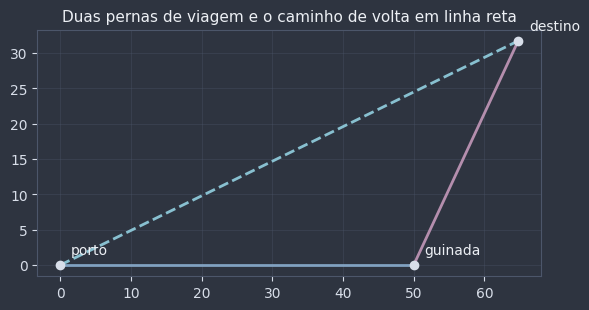

In [5]:
distancia_perna1 = 50.0  # milhas náuticas, rumo original (tomado como referência, 0°)
angulo_guinada = 65.0  # graus, quanto o navio desvia do rumo original ao mudar de direção
distancia_perna2 = 35.0  # milhas náuticas, na nova direção

angulo_interno_guinada = 180 - angulo_guinada  # ângulo interno do triângulo no ponto de guinada

distancia_final = math.sqrt(
    distancia_perna1 ** 2 + distancia_perna2 ** 2
    - 2 * distancia_perna1 * distancia_perna2 * math.cos(math.radians(angulo_interno_guinada))
)

# ângulo, no ponto de partida, entre o rumo original e a linha até a posição final —
# pela Lei dos Senos, já que conhecemos o lado oposto (distancia_perna2) e o ângulo oposto a ele
angulo_ate_destino = math.degrees(
    math.asin(distancia_perna2 * math.sin(math.radians(angulo_interno_guinada)) / distancia_final)
)
rumo_de_retorno = (angulo_ate_destino + 180) % 360  # rumo oposto ao da ida

print(f"distância em linha reta até a posição final: {distancia_final:.2f} milhas náuticas")
print(f"desvio em relação ao rumo original: {angulo_ate_destino:.2f}°")
print(f"rumo de retorno (relativo ao rumo original): {rumo_de_retorno:.2f}°")

porto = (0.0, 0.0)
ponto_guinada = (distancia_perna1, 0.0)
destino = (
    ponto_guinada[0] + distancia_perna2 * math.cos(math.radians(angulo_guinada)),
    ponto_guinada[1] + distancia_perna2 * math.sin(math.radians(angulo_guinada)),
)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot([porto[0], ponto_guinada[0]], [porto[1], ponto_guinada[1]], color=COR_SECUNDARIA, linewidth=2)
ax.plot([ponto_guinada[0], destino[0]], [ponto_guinada[1], destino[1]], color=COR_EXTRA, linewidth=2)
ax.plot([porto[0], destino[0]], [porto[1], destino[1]], color=COR_PONTO, linewidth=2, linestyle="--")
for ponto, nome in [(porto, "porto"), (ponto_guinada, "guinada"), (destino, "destino")]:
    ax.plot(*ponto, "o", color=NORD_TEXTO_SEC)
    ax.annotate(nome, xy=(ponto[0] + 1.5, ponto[1] + 1.5), color=NORD_TEXTO, fontsize=10)
ax.set_aspect("equal")
ax.set_title("Duas pernas de viagem e o caminho de volta em linha reta", color=NORD_TEXTO, fontsize=11)
plt.show()

⚠️ **Erro comum:** usar o ângulo errado na Lei dos Cossenos. A fórmula c² = a² + b² − 2ab·cos C sempre usa o ângulo **oposto** ao lado que está sendo calculado (aqui, C é oposto a c) — nunca um ângulo qualquer do triângulo.

**Pergunta de checagem:** por que a Lei dos Cossenos "vira" o Teorema de Pitágoras quando o ângulo C é 90°?

📖 **Leitura complementar:** [Lei dos cossenos — Wikipédia](https://pt.wikipedia.org/wiki/Lei_dos_cossenos)

## 4. Área do Triângulo com Trigonometria

A fórmula clássica da área é base × altura / 2. Tomando o lado a como base e observando o triângulo retângulo formado pela altura relativa a esse lado, essa altura pode ser escrita como b·sen C — sem precisar medir ou desenhar a altura diretamente. Substituindo:

**Área = ½·a·b·sen C**

(o ângulo C é o ângulo **entre** os lados a e b usados na fórmula — troque a, b, C por qualquer outro par de lados e o ângulo entre eles, o resultado é o mesmo).

Quando nenhum ângulo é conhecido, mas os três lados sim, a **Fórmula de Herão** resolve o problema:

**Área = √(s(s−a)(s−b)(s−c))**, com **s = (a+b+c)/2** (o semiperímetro).

In [6]:
lado_area_a = 8.0
lado_area_b = 6.0
angulo_area_c_graus = 50.0  # ângulo entre os lados a e b

area_trigonometrica = 0.5 * lado_area_a * lado_area_b * math.sin(math.radians(angulo_area_c_graus))

# terceiro lado via Lei dos Cossenos, para poder conferir com a Fórmula de Herão
lado_area_c = math.sqrt(
    lado_area_a ** 2 + lado_area_b ** 2
    - 2 * lado_area_a * lado_area_b * math.cos(math.radians(angulo_area_c_graus))
)
semi_perimetro = (lado_area_a + lado_area_b + lado_area_c) / 2
area_heron = math.sqrt(
    semi_perimetro
    * (semi_perimetro - lado_area_a)
    * (semi_perimetro - lado_area_b)
    * (semi_perimetro - lado_area_c)
)

print(f"área (fórmula trigonométrica ½·a·b·sen C): {area_trigonometrica:.4f}")
print(f"área (Fórmula de Herão): {area_heron:.4f}")
assert abs(area_trigonometrica - area_heron) < 1e-9
print("As duas fórmulas concordam.")

área (fórmula trigonométrica ½·a·b·sen C): 18.3851
área (Fórmula de Herão): 18.3851
As duas fórmulas concordam.


💡 **Dica:** a fórmula trigonométrica da área (½·a·b·sen C) é especialmente útil quando você já conhece dois lados e o ângulo entre eles — exatamente o caso LAL, o mesmo em que a Lei dos Cossenos entra em ação no Bloco 3.

**Pergunta de checagem:** por que não é preciso conhecer a altura do triângulo para calcular sua área com a fórmula ½·a·b·sen C?

📖 **Leitura complementar:** [Teorema de Herão — Wikipédia](https://pt.wikipedia.org/wiki/Teorema_de_Her%C3%A3o)

## 5. Resolução de Triângulos Quaisquer

**Resolver um triângulo** significa encontrar todos os seus lados e ângulos a partir de um subconjunto mínimo de dados. Com três lados ou ângulos conhecidos (nem todos ângulos, como vimos), existe um "fluxograma de decisão":

- **ALA/AAL** (dois ângulos e um lado): terceiro ângulo por soma 180°, depois Lei dos Senos para os lados.
- **LAL** (dois lados e o ângulo entre eles): Lei dos Cossenos para o terceiro lado, depois Lei dos Cossenos (ou Senos) para os ângulos restantes.
- **LLL** (os três lados): Lei dos Cossenos para todos os ângulos.
- **LLA** (dois lados e o ângulo oposto a um deles): caso **ambíguo** — pode ter 0, 1 ou 2 triângulos possíveis, e exige atenção especial (não dá para simplesmente aplicar uma fórmula direta).

Função validada nos casos LLL e ALA.


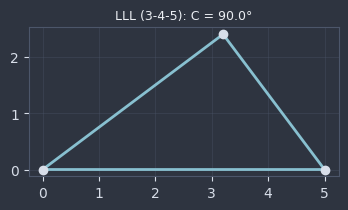

In [7]:
def resolver_triangulo(
    *,
    lado_a: float | None = None,
    lado_b: float | None = None,
    lado_c: float | None = None,
    angulo_a_graus: float | None = None,
    angulo_b_graus: float | None = None,
    angulo_c_graus: float | None = None,
) -> dict[str, float]:
    """Resolve um triângulo qualquer a partir de exatamente três dados válidos (entre os três
    lados e os três ângulos), aplicando automaticamente a Lei dos Cossenos e/ou a Lei dos
    Senos conforme o caso (LLL, LAL ou ALA/AAL). O caso LLA (dois lados e o ângulo oposto a
    um deles) é ambíguo e deve ser tratado por `resolver_triangulo_lla`."""
    lados = {"a": lado_a, "b": lado_b, "c": lado_c}
    angulos = {"a": angulo_a_graus, "b": angulo_b_graus, "c": angulo_c_graus}
    n_lados = sum(valor is not None for valor in lados.values())
    n_angulos = sum(valor is not None for valor in angulos.values())

    if n_lados + n_angulos != 3:
        raise ValueError("Informe exatamente três dados (entre lados e ângulos).")
    if n_angulos == 3:
        raise ValueError(
            "Conhecer os três ângulos (AAA) não é suficiente: isso fixa a forma, mas não o "
            "tamanho do triângulo — é preciso pelo menos um lado."
        )

    if n_lados == 3:
        # Caso LLL: Lei dos Cossenos para os três ângulos
        angulo_a_graus = math.degrees(math.acos((lado_b ** 2 + lado_c ** 2 - lado_a ** 2) / (2 * lado_b * lado_c)))
        angulo_b_graus = math.degrees(math.acos((lado_a ** 2 + lado_c ** 2 - lado_b ** 2) / (2 * lado_a * lado_c)))
        angulo_c_graus = 180 - angulo_a_graus - angulo_b_graus
    elif n_lados == 2:
        # Caso LAL: dois lados e o ângulo entre eles (o único ângulo informado)
        if angulo_a_graus is not None and lado_b is not None and lado_c is not None:
            lado_a = math.sqrt(lado_b ** 2 + lado_c ** 2 - 2 * lado_b * lado_c * math.cos(math.radians(angulo_a_graus)))
        elif angulo_b_graus is not None and lado_a is not None and lado_c is not None:
            lado_b = math.sqrt(lado_a ** 2 + lado_c ** 2 - 2 * lado_a * lado_c * math.cos(math.radians(angulo_b_graus)))
        elif angulo_c_graus is not None and lado_a is not None and lado_b is not None:
            lado_c = math.sqrt(lado_a ** 2 + lado_b ** 2 - 2 * lado_a * lado_b * math.cos(math.radians(angulo_c_graus)))
        else:
            raise ValueError(
                "Dois lados e um ângulo que não está entre eles formam o caso ambíguo LLA — "
                "use resolver_triangulo_lla."
            )
        # com os três lados em mãos, os ângulos saem pela Lei dos Cossenos, sem ambiguidade
        angulo_a_graus = math.degrees(math.acos((lado_b ** 2 + lado_c ** 2 - lado_a ** 2) / (2 * lado_b * lado_c)))
        angulo_b_graus = math.degrees(math.acos((lado_a ** 2 + lado_c ** 2 - lado_b ** 2) / (2 * lado_a * lado_c)))
        angulo_c_graus = 180 - angulo_a_graus - angulo_b_graus
    else:
        # Caso ALA/AAL: dois ângulos e um lado -> terceiro ângulo por soma 180°,
        # depois Lei dos Senos para os lados restantes
        if angulo_a_graus is None:
            angulo_a_graus = 180 - angulo_b_graus - angulo_c_graus
        elif angulo_b_graus is None:
            angulo_b_graus = 180 - angulo_a_graus - angulo_c_graus
        else:
            angulo_c_graus = 180 - angulo_a_graus - angulo_b_graus

        if lado_a is not None:
            razao = lado_a / math.sin(math.radians(angulo_a_graus))
        elif lado_b is not None:
            razao = lado_b / math.sin(math.radians(angulo_b_graus))
        else:
            razao = lado_c / math.sin(math.radians(angulo_c_graus))

        lado_a = razao * math.sin(math.radians(angulo_a_graus)) if lado_a is None else lado_a
        lado_b = razao * math.sin(math.radians(angulo_b_graus)) if lado_b is None else lado_b
        lado_c = razao * math.sin(math.radians(angulo_c_graus)) if lado_c is None else lado_c

    return {
        "lado_a": lado_a, "lado_b": lado_b, "lado_c": lado_c,
        "angulo_a_graus": angulo_a_graus, "angulo_b_graus": angulo_b_graus, "angulo_c_graus": angulo_c_graus,
    }


# Caso LLL: o triângulo 3-4-5 deve ter o ângulo C (oposto ao lado 5) igual a 90°
teste_lll = resolver_triangulo(lado_a=3, lado_b=4, lado_c=5)
assert abs(teste_lll["angulo_c_graus"] - 90) < 1e-6

# Caso ALA: dois ângulos e o lado entre eles
teste_ala = resolver_triangulo(angulo_a_graus=50, angulo_b_graus=70, lado_c=12)
assert abs(teste_ala["angulo_a_graus"] + teste_ala["angulo_b_graus"] + teste_ala["angulo_c_graus"] - 180) < 1e-6

print("Função validada nos casos LLL e ALA.")
desenhar_triangulo_generico(
    teste_lll["lado_a"], teste_lll["lado_b"], teste_lll["lado_c"],
    titulo=f"LLL (3-4-5): C = {teste_lll['angulo_c_graus']:.1f}°",
)

In [8]:
def resolver_triangulo_lla(lado_a: float, lado_b: float, angulo_a_graus: float) -> list[dict[str, float]]:
    """Resolve o caso ambíguo LLA — lado a, lado b e o ângulo A oposto a `lado_a` — devolvendo
    uma lista com 0, 1 ou 2 soluções possíveis (uma lista vazia quando nenhum triângulo existe)."""
    seno_b = lado_b * math.sin(math.radians(angulo_a_graus)) / lado_a
    if seno_b > 1 + 1e-9:
        return []

    angulos_b_graus = [math.degrees(math.asin(min(seno_b, 1.0)))]
    if seno_b < 1 - 1e-9:
        angulos_b_graus.append(180 - angulos_b_graus[0])

    solucoes = []
    for angulo_b_graus in angulos_b_graus:
        angulo_c_graus = 180 - angulo_a_graus - angulo_b_graus
        if angulo_c_graus <= 0:
            continue
        lado_c = lado_a * math.sin(math.radians(angulo_c_graus)) / math.sin(math.radians(angulo_a_graus))
        solucoes.append({
            "lado_a": lado_a, "lado_b": lado_b, "lado_c": lado_c,
            "angulo_a_graus": angulo_a_graus, "angulo_b_graus": angulo_b_graus, "angulo_c_graus": angulo_c_graus,
        })
    return solucoes


casos_lla = {
    "duas soluções (a=8, b=10, A=40°)": resolver_triangulo_lla(8, 10, 40),
    "uma solução (a=10, b=10, A=40°)": resolver_triangulo_lla(10, 10, 40),
    "zero soluções (a=4, b=10, A=40°)": resolver_triangulo_lla(4, 10, 40),
}
for descricao, solucoes in casos_lla.items():
    print(f"{descricao}: {len(solucoes)} solução(ões)")
    for solucao in solucoes:
        print(f"    B = {solucao['angulo_b_graus']:.1f}°   C = {solucao['angulo_c_graus']:.1f}°   c = {solucao['lado_c']:.2f}")

duas soluções (a=8, b=10, A=40°): 2 solução(ões)
    B = 53.5°   C = 86.5°   c = 12.42
    B = 126.5°   C = 13.5°   c = 2.90
uma solução (a=10, b=10, A=40°): 1 solução(ões)
    B = 40.0°   C = 100.0°   c = 15.32
zero soluções (a=4, b=10, A=40°): 0 solução(ões)


🕵️ **Curiosidade histórica:** antes das calculadoras, resolver triângulos era tão importante para navegação e agrimensura que existiam livros inteiros de **tábuas trigonométricas** dedicados só a isso — tabelas com o seno, cosseno e tangente de milhares de ângulos, consultadas manualmente por navegadores, engenheiros e artilheiros.

**Pergunta de checagem:** dados os três ângulos de um triângulo, sem nenhum lado, é possível resolvê-lo completamente? Por quê?

## 6. Aplicação Final: GPS, Triangulação e o Desafio Integrador

Sistemas de posicionamento — GPS, triangulação de celular, agrimensura moderna — usam essencialmente o mesmo princípio deste notebook: medir distâncias ou ângulos a partir de pontos de referência **conhecidos** e usar as leis dos senos e cossenos (ou suas versões em três dimensões) para calcular a posição de um ponto **desconhecido**.

Vamos fechar o módulo com um desafio que combina as duas leis em sequência: duas estações de rastreamento em terra, com distância conhecida entre elas, medem os ângulos até um avião.

In [9]:
base_estacoes = 15.0  # km, distância entre as duas estações de rastreamento
angulo_estacao1_graus = 75.0  # graus, ângulo medido na estação 1 até o avião
angulo_estacao2_graus = 65.0  # graus, ângulo medido na estação 2 até o avião

angulo_aviao_graus = 180 - angulo_estacao1_graus - angulo_estacao2_graus

# Passo 1 (Lei dos Senos): distância de cada estação até o avião
distancia_estacao1_aviao = lei_dos_senos_lado(base_estacoes, angulo_aviao_graus, angulo_estacao2_graus)
distancia_estacao2_aviao = lei_dos_senos_lado(base_estacoes, angulo_aviao_graus, angulo_estacao1_graus)

print(f"distância da estação 1 até o avião: {distancia_estacao1_aviao:.2f} km")
print(f"distância da estação 2 até o avião: {distancia_estacao2_aviao:.2f} km")

# Passo 2 (Lei dos Cossenos): distância do avião até um terceiro ponto de referência
# (um aeroporto), conhecendo a distância da estação 1 até o aeroporto e o ângulo entre
# a linha estação1-avião e a linha estação1-aeroporto
distancia_estacao1_aeroporto = 20.0  # km
angulo_aviao_aeroporto = 50.0  # graus, visto da estação 1

distancia_aviao_aeroporto = math.sqrt(
    distancia_estacao1_aviao ** 2 + distancia_estacao1_aeroporto ** 2
    - 2 * distancia_estacao1_aviao * distancia_estacao1_aeroporto * math.cos(math.radians(angulo_aviao_aeroporto))
)

print(f"distância do avião até o aeroporto de referência: {distancia_aviao_aeroporto:.2f} km")

distância da estação 1 até o avião: 21.15 km
distância da estação 2 até o avião: 22.54 km
distância do avião até o aeroporto de referência: 17.42 km


🕹️ **Widget interativo:** mexa nos ângulos medidos em cada estação e veja o triângulo estação–estação–avião, e as duas distâncias calculadas pela Lei dos Senos, sendo atualizados ao vivo.

In [10]:
def widget_rastreamento_aviao(angulo_estacao1_graus: float, angulo_estacao2_graus: float) -> None:
    """Recalcula e desenha o triângulo estação-estação-avião para os ângulos medidos em cada
    estação, mantendo a base entre estações fixa."""
    angulo_aviao_graus = 180 - angulo_estacao1_graus - angulo_estacao2_graus
    if angulo_aviao_graus <= 0:
        print("Ângulos incompatíveis: a soma deve ser menor que 180°.")
        return

    dist1 = lei_dos_senos_lado(base_estacoes, angulo_aviao_graus, angulo_estacao2_graus)
    dist2 = lei_dos_senos_lado(base_estacoes, angulo_aviao_graus, angulo_estacao1_graus)
    aviao_x = dist1 * math.cos(math.radians(angulo_estacao1_graus))
    aviao_y = dist1 * math.sin(math.radians(angulo_estacao1_graus))

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    estacao1, estacao2, aviao = (0.0, 0.0), (base_estacoes, 0.0), (aviao_x, aviao_y)
    for origem, destino, cor in [
        (estacao1, aviao, COR_SECUNDARIA), (estacao2, aviao, COR_EXTRA), (estacao1, estacao2, NORD_TEXTO_SEC),
    ]:
        ax.plot([origem[0], destino[0]], [origem[1], destino[1]], color=cor, linewidth=2)

    for ponto, nome in [(estacao1, "estação 1"), (estacao2, "estação 2"), (aviao, "avião")]:
        ax.plot(*ponto, "o", color=NORD_TEXTO_SEC)
        ax.annotate(nome, xy=(ponto[0] + base_estacoes * 0.02, ponto[1] + base_estacoes * 0.02), color=NORD_TEXTO, fontsize=10)

    ax.set_xlim(-base_estacoes * 0.15, base_estacoes * 1.15)
    ax.set_ylim(-base_estacoes * 0.15, max(aviao_y * 1.25, base_estacoes * 0.3))
    ax.set_aspect("equal")
    ax.set_title(f"estação 1 → avião: {dist1:.1f} km   estação 2 → avião: {dist2:.1f} km", color=NORD_TEXTO, fontsize=10)
    plt.show()


widgets.interact(
    widget_rastreamento_aviao,
    angulo_estacao1_graus=widgets.IntSlider(min=30, max=85, step=1, value=75, description="ângulo est.1 (°)"),
    angulo_estacao2_graus=widgets.IntSlider(min=30, max=85, step=1, value=65, description="ângulo est.2 (°)"),
)

interactive(children=(IntSlider(value=75, description='ângulo est.1 (°)', max=85, min=30), IntSlider(value=65,…

<function __main__.widget_rastreamento_aviao(angulo_estacao1_graus: float, angulo_estacao2_graus: float) -> None>

🔗 **Conexão:** este bloco fecha o módulo inteiro de Trigonometria, reunindo ferramentas de praticamente todos os notebooks anteriores — funções circulares, redução ao 1º quadrante, arcos notáveis, transformações, equações e, agora, as leis dos triângulos.

**Pergunta de checagem (síntese do módulo):** quais dos notebooks anteriores deste módulo você usaria, e em que ordem, para resolver esse problema de rastreamento do início ao fim?

📖 **Leitura complementar:** [Sistema de posicionamento global — Wikipédia](https://pt.wikipedia.org/wiki/Sistema_de_posicionamento_global)

## Resumo — cheat sheet

**Propriedades gerais de qualquer triângulo:** soma dos ângulos internos = 180°; desigualdade triangular (a soma de dois lados quaisquer é maior que o terceiro); classificação por lados (equilátero, isósceles, escaleno) e por ângulos (acutângulo, retângulo, obtusângulo).

**Lei dos Senos:** a/sen A = b/sen B = c/sen C = 2R (R = raio da circunferência circunscrita). Use quando souber dois ângulos e um lado (ALA/AAL), ou dois lados e o ângulo oposto a um deles (LLA — caso ambíguo).

**Lei dos Cossenos:** c² = a² + b² − 2ab·cos C (e permutações análogas para a² e b²). Generaliza o Teorema de Pitágoras (quando C=90°, cos C=0). Use quando souber os três lados (LLL) ou dois lados e o ângulo entre eles (LAL).

**Área do triângulo:** Área = ½·a·b·sen C (ângulo entre os lados a e b), ou pela Fórmula de Herão: Área = √(s(s−a)(s−b)(s−c)), com s = (a+b+c)/2.

**Para resolver um triângulo qualquer:**
- ✅ ALA/AAL (dois ângulos e um lado) → Lei dos Senos.
- ✅ LAL (dois lados e o ângulo entre eles) → Lei dos Cossenos, depois Lei dos Senos.
- ✅ LLL (os três lados) → Lei dos Cossenos para todos os ângulos.
- ⚠️ LLA (dois lados e o ângulo oposto a um deles) → caso ambíguo, pode ter 0, 1 ou 2 soluções.
- ❌ AAA (os três ângulos sozinhos) → fixa a forma, não o tamanho.

## Exercícios

### Básico

In [ ]:
# Exercício Básico 1: um triângulo tem ângulo A = 50°, ângulo B = 70° e lado a = 10
# (oposto ao ângulo A). Calcule o lado b (oposto ao ângulo B) usando a Lei dos Senos
# (seção 2) e guarde o resultado em lado_b_ex1.
lado_b_ex1 = ...

print(lado_b_ex1)

In [ ]:
# Verificação
esperado_ex1 = lei_dos_senos_lado(10, 50, 70)
assert abs(lado_b_ex1 - esperado_ex1) < 1e-6, (
    "Tente de novo, revise: use lei_dos_senos_lado(10, 50, 70), ou seja, "
    "b = a*sen(B)/sen(A) (seção 2 - Lei dos Senos)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: um triângulo tem lados a = 7 e b = 9, com um ângulo de 40° entre
# eles. Calcule a área do triângulo usando a fórmula trigonométrica (seção 4) e guarde
# o resultado em area_ex2.
area_ex2 = ...

print(area_ex2)

In [ ]:
# Verificação
esperado_ex2 = 0.5 * 7 * 9 * math.sin(math.radians(40))
assert abs(area_ex2 - esperado_ex2) < 1e-6, (
    "Tente de novo, revise: Área = 0.5 * 7 * 9 * math.sin(math.radians(40)) "
    "(seção 4 - Área do Triângulo com Trigonometria)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: resolva o triângulo com lado a = 8, lado b = 6 e o ângulo
# de 55° entre eles (caso LAL), usando resolver_triangulo (seção 5). Guarde o
# dicionário retornado em resultado_ex3.
resultado_ex3 = ...

print(resultado_ex3)

In [ ]:
# Verificação
esperado_ex3 = resolver_triangulo(lado_a=8, lado_b=6, angulo_c_graus=55)
assert resultado_ex3 == esperado_ex3, (
    "Tente de novo, revise: use resolver_triangulo(lado_a=8, lado_b=6, angulo_c_graus=55) "
    "(seção 5 - Resolução de Triângulos Quaisquer)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: um triângulo tem lado a = 9, lado b = 13 e o ângulo A = 35°
# (oposto ao lado a) — o caso ambíguo LLA. Use resolver_triangulo_lla (seção 5) para
# encontrar todas as soluções e guarde a quantidade de soluções em numero_solucoes_ex4.
numero_solucoes_ex4 = ...

print(numero_solucoes_ex4)

In [ ]:
# Verificação
esperado_ex4 = len(resolver_triangulo_lla(9, 13, 35))
assert numero_solucoes_ex4 == esperado_ex4, (
    "Tente de novo, revise: use len(resolver_triangulo_lla(9, 13, 35)) "
    "(seção 5 - Resolução de Triângulos Quaisquer)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: repita o desafio do Bloco 6 com dados diferentes. Duas estações
# de rastreamento, separadas por 20 km, medem ângulos de 80° (estação 1) e 60°
# (estação 2) até um avião. Um aeroporto de referência está a 25 km da estação 1,
# formando um ângulo de 45° com a linha estação1-avião (visto da estação 1). Calcule,
# em duas etapas (Lei dos Senos e depois Lei dos Cossenos), a distância do avião até o
# aeroporto e guarde o resultado em distancia_aviao_aeroporto_ex5.
distancia_aviao_aeroporto_ex5 = ...

print(distancia_aviao_aeroporto_ex5)

In [ ]:
# Verificação
angulo_aviao_ex5 = 180 - 80 - 60
distancia_estacao1_aviao_ex5 = lei_dos_senos_lado(20, angulo_aviao_ex5, 60)
esperado_ex5 = math.sqrt(
    distancia_estacao1_aviao_ex5 ** 2 + 25 ** 2
    - 2 * distancia_estacao1_aviao_ex5 * 25 * math.cos(math.radians(45))
)
assert abs(distancia_aviao_aeroporto_ex5 - esperado_ex5) < 1e-6, (
    "Tente de novo, revise: primeiro ache a distância estação1-avião pela Lei dos Senos, "
    "depois use a Lei dos Cossenos com o lado de 25 km e o ângulo de 45° "
    "(seção 6 - Aplicação Final: GPS, Triangulação e o Desafio Integrador)."
)
print("Certo!")

**Reflexão escrita (fecha o módulo):** liste, em ordem, quais notebooks deste módulo de Trigonometria você usaria para resolver um problema de navegação do início ao fim — desde a definição de ângulo até a Lei dos Cossenos. Não existe uma única resposta certa: o importante é justificar por que cada um entra na sequência que você escolheu.

## Glossário do bloco

| Termo | Definição |
|---|---|
| Desigualdade triangular | a soma de dois lados quaisquer de um triângulo é sempre maior que o terceiro |
| Lei dos Senos | a/sen A = b/sen B = c/sen C = 2R, onde R é o raio da circunferência circunscrita |
| Circunferência circunscrita | circunferência que passa pelos três vértices de um triângulo |
| Lei dos Cossenos | c² = a² + b² − 2ab·cos C; generaliza o Teorema de Pitágoras para qualquer triângulo |
| Fórmula de Herão | Área = √(s(s−a)(s−b)(s−c)), com s = semiperímetro, usada quando só se conhecem os três lados |
| Caso LLA (ambíguo) | dois lados e o ângulo oposto a um deles; pode ter 0, 1 ou 2 triângulos possíveis |
| Resolver um triângulo | encontrar todos os lados e ângulos a partir de um subconjunto mínimo de dados |

## Conexões

**Isso depende de:**
- [`0509a_triangulos_retangulos.ipynb`](0509a_triangulos_retangulos.ipynb) (usado diretamente nas deduções da Lei dos Senos e da Lei dos Cossenos)
- [`0505a_arcos_notaveis.ipynb`](0505a_arcos_notaveis.ipynb) (valores exatos usados nos exemplos)
- [`0506a_transformacoes.ipynb`](0506a_transformacoes.ipynb) (a Lei dos Cossenos também pode ser deduzida a partir das fórmulas de adição de arcos)

**Isso será usado em:**
- [`06_geometria_espacial/`](../06_geometria_espacial/) (próximo módulo do curso — triângulos quaisquer aparecem com frequência em problemas envolvendo sólidos)
- [`07_geometria_analitica_plana_e_espacial/`](../07_geometria_analitica_plana_e_espacial/) (cálculo de distâncias e ângulos entre pontos se apoia diretamente na Lei dos Cossenos)

**Isso encerra o módulo de Trigonometria.** Os dez notebooks, do ciclo trigonométrico até as leis dos triângulos, formam a base para os módulos de Geometria Espacial e Geometria Analítica que vêm a seguir na trilha do curso.